In [1]:
import pandas as pd 

In [2]:
import re

pattern = re.compile(
    r'^(\w{3}\s+\d+\s+\d+:\d+:\d+)\s+'  # date
    r'\S+\s+kernel:.*?\s+'               # host + kernel
    r'(PERMIT|DENY)\s+'                  # action
    r'FW=\S+\s+'                         # fw (à ignorer)
    r'RULE=(\S+)\s+'                     # rule_id
    r'IN=(\S*)\s+'                       # interface_in
    r'OUT=(\S*)\s+'                      # interface_out
    r'.*?'                               # MAC etc.
    r'SRC=(\S+)\s+'                      # ip_src
    r'DST=(\S+)\s+'                      # ip_dst
    r'.*?'                               # LEN TOS etc.
    r'PROTO=(\S+)\s+'                    # protocol
    r'SPT=(\d+)\s+'                      # port_src
    r'DPT=(\d+)'                         # port_dst
)

def parse_line(line):
    m = pattern.search(line)
    if m:
        return m.groups()
    return None

# test sur une ligne
sample = 'Mar 20 01:29:24 159.84.146.99 kernel: [54783294.108218] DENY FW=6 RULE=999 IN=eth0 OUT= MAC=c4:37:72:f9:da:ed:fe:37:72:f9:da:ed:08:00 SRC=94.102.61.47 DST=159.84.146.99 LEN=44 TOS=0x00 PREC=0x00 TTL=238 ID=54321 PROTO=TCP SPT=52502 DPT=3178 WINDOW=65535 RES=0x00 SYN URGP=0'
print(parse_line(sample))

('Mar 20 01:29:24', 'DENY', '999', 'eth0', '', '94.102.61.47', '159.84.146.99', 'TCP', '52502', '3178')


In [3]:
cols = ["datetime", "action", "rule_id", "interface_in", "interface_out", "ip_src", "ip_dst", "protocol", "port_src", "port_dst"]

with open("../data_logs/log_brute/log_brute.log", "r") as f:
    rows = [parse_line(line) for line in f]

df = pd.DataFrame([r for r in rows if r is not None], columns=cols)
print(df.shape)
print(df.head(3))

(11997646, 10)
          datetime  action rule_id interface_in interface_out          ip_src  \
0  Mar 20 01:29:24    DENY     999         eth0                  94.102.61.47   
1  Mar 20 01:29:25    DENY     999         eth0                176.111.174.85   
2  Mar 20 01:29:27  PERMIT       1         eth0                 66.249.65.106   

          ip_dst protocol port_src port_dst  
0  159.84.146.99      TCP    52502     3178  
1  159.84.146.99      TCP    48739     2231  
2  159.84.146.99      TCP    50501      443  


In [21]:
df["datetime"] = pd.to_datetime(df["datetime"], format="%b %d %H:%M:%S")

df["datetime"] = df["datetime"].apply(
    lambda x: x.replace(year=2026) if x.month <= 2 else x.replace(year=2025)
)

# Colonnes numériques
df["port_src"] = pd.to_numeric(df["port_src"], errors="coerce")
df["port_dst"] = pd.to_numeric(df["port_dst"], errors="coerce")
df["rule_id"]  = pd.to_numeric(df["rule_id"], errors="coerce")


# Filtrage période
df_filtered = df[
    (df["datetime"] >= "2025-11-01") &
    (df["datetime"] < "2026-03-01")
].copy()

print(df_filtered.shape)
print(df_filtered["datetime"].dt.to_period("M").value_counts().sort_index())
print(df.dtypes)
print(df.shape)

(4572903, 10)
datetime
2025-11    1212335
2025-12    1620630
2026-01    1250863
2026-02     489075
Freq: M, Name: count, dtype: int64
datetime         datetime64[ns]
action                   object
rule_id                   int64
interface_in             object
interface_out            object
ip_src                   object
ip_dst                   object
protocol                 object
port_src                  int64
port_dst                  int64
dtype: object
(11997646, 10)


In [22]:
df_filtered.columns
df_filtered.head()

,datetime,action,rule_id,interface_in,interface_out,ip_src,ip_dst,protocol,port_src,port_dst
7424743,2025-11-12 09:56:37,DENY,999,eth0,,77.90.185.64,159.84.146.99,TCP,55366,65153
7424744,2025-11-12 09:56:37,PERMIT,1,eth0,,47.128.20.252,159.84.146.99,TCP,14436,443
7424745,2025-11-12 09:56:38,PERMIT,1,eth0,,23.22.35.162,159.84.146.99,TCP,55973,443
7424746,2025-11-12 09:56:39,DENY,999,eth0,,79.124.60.150,159.84.146.99,TCP,53744,56283
7424747,2025-11-12 09:56:39,PERMIT,1,eth0,,47.128.20.252,159.84.146.99,TCP,25404,443


In [23]:
print(df_filtered.datetime.head(5))

7424743   2025-11-12 09:56:37
7424744   2025-11-12 09:56:37
7424745   2025-11-12 09:56:38
7424746   2025-11-12 09:56:39
7424747   2025-11-12 09:56:39
Name: datetime, dtype: datetime64[ns]


In [24]:
df_filtered.to_parquet("../data_logs/log_brute/log_clean.parquet", index=False)

In [26]:
# --- Classement des règles firewall ---

top_rules = (
    df_filtered["rule_id"]
    .value_counts()
    .reset_index()
)

top_rules.columns = ["rule_id", "count"]

top_rules.head(20)

,rule_id,count
0,1,3660700
1,999,755909
2,7,38074
3,4,32834
4,8,32827
5,6,24709
6,2,7642
7,9,7642
8,5,6656
9,11,5910


<Figure size 640x480 with 0 Axes>

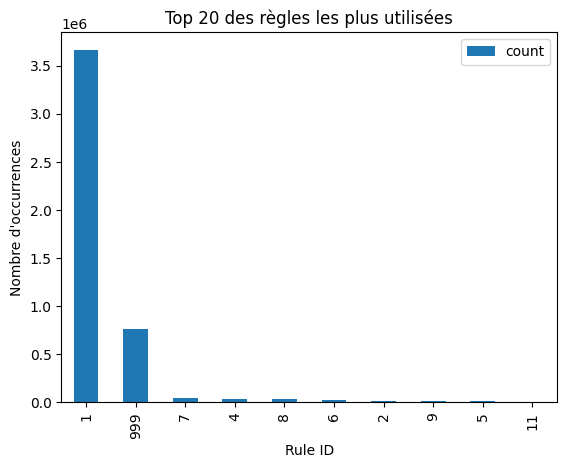

In [27]:
import matplotlib.pyplot as plt

plt.figure()
top_rules.head(20).plot(
    kind="bar",
    x="rule_id",
    y="count"
)

plt.title("Top 20 des règles les plus utilisées")
plt.xlabel("Rule ID")
plt.ylabel("Nombre d'occurrences")
plt.show()

## Répartition des protocoles 

In [11]:
# --- Répartition TCP / UDP ---

proto_counts = df_filtered["protocol"].value_counts()

proto_counts

protocol
TCP    4572903
Name: count, dtype: int64

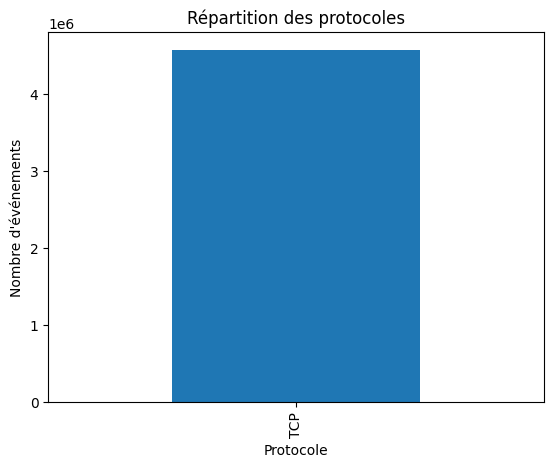

In [12]:
plt.figure()
proto_counts.plot(kind="bar")

plt.title("Répartition des protocoles")
plt.xlabel("Protocole")
plt.ylabel("Nombre d'événements")
plt.show()

In [13]:
df_udp = df_filtered[df_filtered["protocol"] == "UDP"]

top_udp = (
    df_udp["rule_id"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_udp.columns = ["rule_id", "count"]

top_udp

,rule_id,count


In [14]:
df_tcp = df_filtered[df_filtered["protocol"] == "TCP"]

top_tcp = (
    df_tcp["rule_id"]
    .value_counts()
    .head(5)
    .reset_index()
)

top_tcp.columns = ["rule_id", "count"]

top_tcp

,rule_id,count
0,1,3660700
1,999,755909
2,7,38074
3,4,32834
4,8,32827


In [17]:
tcp_analysis = (
    df_tcp
    .groupby(["rule_id", "port_dst", "action"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

tcp_analysis.head(20)

,rule_id,port_dst,action,count
0,1,443,PERMIT,3621944
1,1,80,PERMIT,38756
10,7,23,DENY,38074
4,4,22,PERMIT,32834
11,8,22,PERMIT,32827
9,6,445,DENY,20301
3,2,3306,PERMIT,7642
12,9,3306,PERMIT,7642
63404,999,8080,DENY,7129
6,5,21,DENY,6076


In [18]:
top_ip_src = (
    df_filtered["ip_src"]
    .value_counts()
    .head(5)
    .reset_index()
)

top_ip_src.columns = ["ip_src", "count"]

top_ip_src

,ip_src,count
0,3.224.220.101,773605
1,23.22.35.162,762887
2,52.70.240.171,687748
3,51.79.181.158,68722
4,103.89.91.86,61109


In [28]:
privileged_ports = df_filtered[
    (df_filtered["port_dst"] < 1024) &
    (df_filtered["action"] == "PERMIT")
]

privileged_ports["port_dst"].value_counts().head(10)

port_dst
443    3621944
22       65661
80       38756
110       5910
Name: count, dtype: int64

In [29]:
df_filtered[
    (df_filtered["port_dst"] < 1024) &
    (df_filtered["action"] == "PERMIT")
].groupby(["rule_id", "port_dst"]).size().sort_values(ascending=False).head(10)

rule_id  port_dst
1        443         3621944
         80            38756
4        22            32834
8        22            32827
11       110            5910
dtype: int64

In [30]:
ssh_permit = df_filtered[
    (df_filtered["port_dst"] == 22) &
    (df_filtered["action"] == "PERMIT")
]

ssh_permit["ip_src"].nunique()

4934

In [31]:
df_filtered[
    df_filtered["port_dst"] == 22
]["action"].value_counts()

action
PERMIT    65661
Name: count, dtype: int64

In [32]:
ssh_attempts = df_filtered[df_filtered["port_dst"] == 22]

ssh_per_ip = (
    ssh_attempts
    .groupby("ip_src")
    .size()
    .sort_values(ascending=False)
)

ssh_per_ip.head(10)

ip_src
108.59.13.8       634
218.92.0.99       336
77.90.185.72      326
203.167.14.100    298
61.177.173.45     292
59.110.166.32     250
13.233.7.225      244
208.109.34.15     242
92.205.18.100     240
185.244.25.14     226
dtype: int64